In [1]:
import h5py as h5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy.stats import wasserstein_distance
sns.set_theme(style="whitegrid")

In [2]:
h5_k5 = h5.File('../data/K562_histone_enhancer_marks.h5', 'r')
h5_k5_seq = h5.File('../data/K562_histone_appended_pe_encoding.h5', 'r')
h5_gm = h5.File('../data/GM12878_histone_enhancer_marks.h5', 'r')
h5_gm_seq = h5.File('../data/GM12878_histone_appended_pe_encoding.h5', 'r')
h5_k5.keys(), h5_k5_seq.keys()

(<KeysViewHDF5 ['GM12878', 'H3K27ac', 'H3K27me3', 'H3K36me3', 'H3K4me1', 'H3K4me3', 'H3K9me3', 'methylation']>,
 <KeysViewHDF5 ['H3K27ac', 'H3K27me3', 'H3K36me3', 'H3K4me1', 'H3K4me3', 'H3K9me3', 'distance', 'gene_id', 'pe_seqs']>)

In [3]:
# generate padding mask per sample (first dim) from h5_k5_seq 'pe_seqs' key
# ~(pe_seq.sum(-1).sum(-1) > 0).bool()
padding_mask = ~(h5_k5_seq['pe_seqs'][:].sum(-1).sum(-1) > 0).astype(bool)
padding_mask.shape

(18377, 61)

In [4]:
gene_info = pd.read_csv('../data/leave_chrom_out_crossvalidation_split_18377genes.csv')
gene_info.head()
ensid_to_chrom = dict(zip(gene_info['ENSID'], gene_info['chrom']))

In [9]:
# VOCAB = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
def get_methylation_values(h5_file, h5_seq_file, padding_mask, ensid_to_chrom):
    meth_values = defaultdict(list)
    num_samples = h5_file['methylation'].shape[0]
    promoter = False

    for i in range(num_samples):
        meth = h5_file['methylation'][i]
        seq = h5_seq_file['pe_seqs'][i]
        mask = padding_mask[i]
        gene = h5_seq_file['gene_id'][i].decode('utf-8')
        chrom = ensid_to_chrom.get(gene, None)
        
        # filter out padding
        meth = meth[~mask]
        seq = seq[~mask]

        if promoter: 
            # extract only first sequence
            seq = seq[0, :]
            meth = meth[0, :]
        else:
            seq = seq[1:,:]
            seq = seq.reshape(-1, seq.shape[-1])
            meth = meth[1:, :]
            meth = meth.reshape(-1, meth.shape[-1])

        # consider only positions where nucleotide is C (1)
        valid_positions = seq[:, 1] == 1
        meth = meth[valid_positions]
        
        meth_values[chrom].extend(meth[:, 0])

    return meth_values

# hist plot, two subplots, one for all methylation values, one for x chromosome only
meth_gm = get_methylation_values(h5_gm, h5_gm_seq, padding_mask, ensid_to_chrom)
meth_k5 = get_methylation_values(h5_k5, h5_k5_seq, padding_mask, ensid_to_chrom)
len(meth_gm), len(meth_k5)


(23, 23)

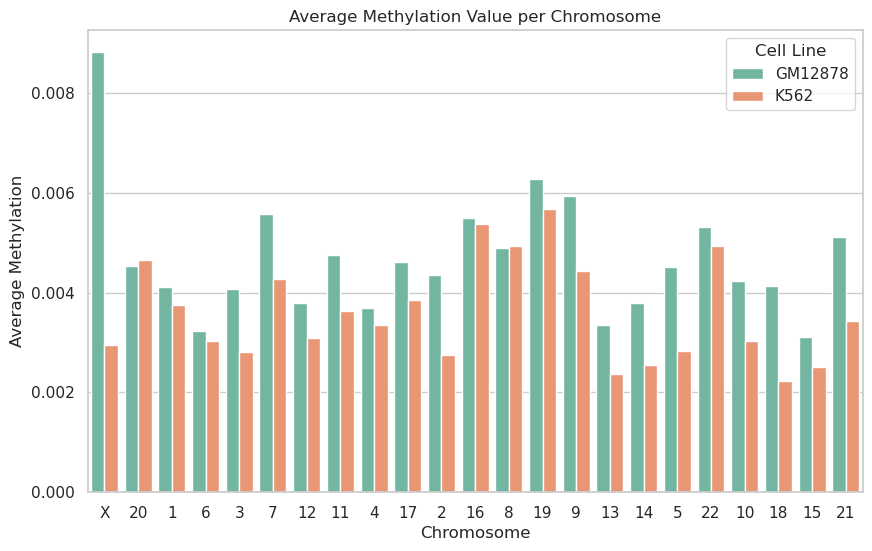

In [10]:
# plot average methylation value per chromosome
palette = sns.color_palette("Set2", n_colors=2)
avg_meth_gm = {chrom: np.mean(values) for chrom, values in meth_gm.items() if len(values) > 0}
avg_meth_k5 = {chrom: np.mean(values) for chrom, values in meth_k5.items() if len(values) > 0}
avg_meth_df = pd.DataFrame({
    'GM12878': pd.Series(avg_meth_gm),
    'K562': pd.Series(avg_meth_k5)
}).reset_index().melt(id_vars='index', var_name='Cell Line', value_name='Average Methylation')
avg_meth_df.rename(columns={'index': 'Chromosome'}, inplace=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_meth_df, x='Chromosome', y='Average Methylation', hue='Cell Line', palette=palette)
plt.title('Average Methylation Value per Chromosome')
plt.show()

In [11]:
avg_meth_df

,Chromosome,Cell Line,Average Methylation
0,X,GM12878,0.008812
1,20,GM12878,0.004525
2,1,GM12878,0.004110
3,6,GM12878,0.003224
4,3,GM12878,0.004065
5,7,GM12878,0.005564
6,12,GM12878,0.003783
7,11,GM12878,0.004742
8,4,GM12878,0.003687
9,17,GM12878,0.004604


In [12]:
# put meth values per chromosomes in 20 bins and normalize
def get_binned_distribution(meth_values, num_bins=20):
    binned_dist = {}
    for chrom, values in meth_values.items():
        if len(values) > 0:
            hist, bin_edges = np.histogram(values, bins=num_bins, range=(0, 1), density=False)
            binned_dist[chrom] = hist / hist.sum()  # normalize
    return binned_dist

binned_gm = get_binned_distribution(meth_gm)
binned_k5 = get_binned_distribution(meth_k5)

In [13]:
def wasserstein_chromosomes(meth_values):
    distances = defaultdict(dict)
    for chrom in meth_values.keys():
        for chrom_2 in meth_values.keys():
            # normalize and take from distribution
            dist = wasserstein_distance(meth_values[chrom], meth_values[chrom_2])
            distances[chrom][chrom_2] = dist
    return distances

# plot wasserstein distance as matrix
wd_gm = wasserstein_chromosomes(binned_gm)
wd_k5 = wasserstein_chromosomes(binned_k5)
wd_gm_df = pd.DataFrame(wd_gm)
wd_k5_df = pd.DataFrame(wd_k5)
# sort alphanumerically
wd_gm_df = wd_gm_df.reindex(sorted(wd_gm_df.columns), axis=1).reindex(sorted(wd_gm_df.index), axis=0)
wd_k5_df = wd_k5_df.reindex(sorted(wd_k5_df.columns), axis=1).reindex(sorted(wd_k5_df.index), axis=0)

In [14]:
wd_gm_df.max().max(), wd_k5_df.max().max()

(0.0014736601768646543, 0.0006079802213474682)

In [15]:
h5_events = h5.File('../data/event_bp_histone_marks.h5', 'r')
h5_seq = h5.File('../data/event_encoding.h5', 'r')
h5_events['K562'].keys(), h5_seq.keys()

(<KeysViewHDF5 ['H3K27ac', 'H3K27me3', 'H3K36me3', 'H3K4me1', 'H3K4me3', 'H3K9me3', 'methylation']>,
 <KeysViewHDF5 ['H3K27ac_GM12878', 'H3K27ac_K562', 'H3K27me3_GM12878', 'H3K27me3_K562', 'H3K36me3_GM12878', 'H3K36me3_K562', 'H3K4me1_GM12878', 'H3K4me1_K562', 'H3K4me3_GM12878', 'H3K4me3_K562', 'H3K9me3_GM12878', 'H3K9me3_K562', 'event_id', 'event_seq', 'gene_id']>)

In [16]:
def get_event_methylation_values(h5_file, h5_seq_file, ensid_to_chrom, cell='K562'):
    meth_values = defaultdict(list)
    num_samples = h5_file[cell]['methylation'].shape[0]
    x_genes = set()
    x_events = []

    for i in range(num_samples):
        meth = h5_file[cell]['methylation'][i]
        seq = h5_seq_file['event_seq'][i]
        gene = h5_seq_file['gene_id'][i].decode('utf-8')
        chrom = ensid_to_chrom.get(gene, None)
        
        #seq = seq[1, :] # only look at the central sequence
        #meth = meth[1, :] # only look at the central methylation
        
        # mask positions where sequence is all zeros
        valid_positions = seq.sum(axis=-1) != 0
        meth = meth[valid_positions]
        
        if chrom == 'X':
            x_genes.add(gene)
            x_events.append(i)
        meth_values[chrom].extend(meth[:, 0])

    print("Number of X chromosome genes:", len(x_genes), "\nNumber of X chromosome events:", len(x_events))
    return meth_values

In [17]:
ev_meth_gm = get_event_methylation_values(h5_events, h5_seq, ensid_to_chrom, cell='GM12878')
ev_meth_k5 = get_event_methylation_values(h5_events, h5_seq, ensid_to_chrom, cell='K562')
print(len(ev_meth_gm), len(ev_meth_k5))

Number of X chromosome genes: 348 
Number of X chromosome events: 731
Number of X chromosome genes: 348 
Number of X chromosome events: 731
23 23


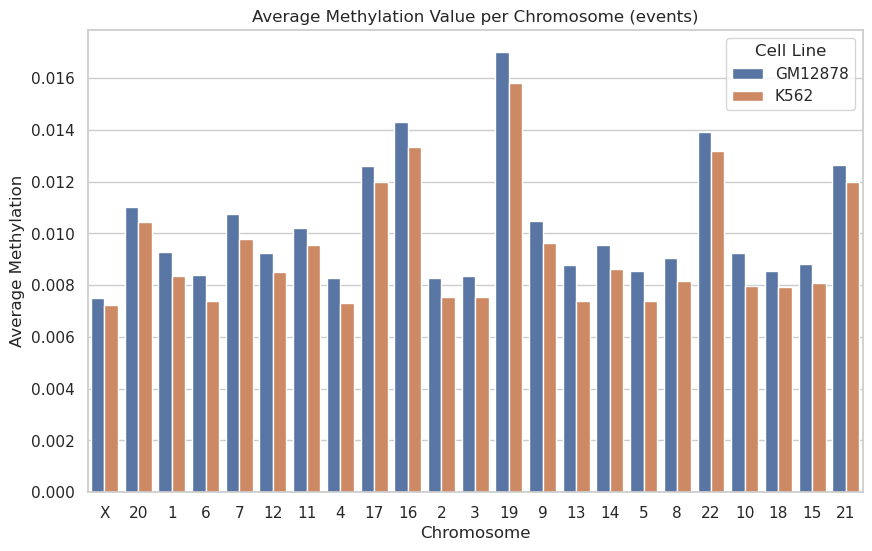

In [18]:
# plot average methylation value per chromosome
avg_meth_gm = {chrom: np.mean(values) for chrom, values in ev_meth_gm.items() if len(values) > 0}
avg_meth_k5 = {chrom: np.mean(values) for chrom, values in ev_meth_k5.items() if len(values) > 0}
avg_meth_df = pd.DataFrame({
    'GM12878': pd.Series(avg_meth_gm),
    'K562': pd.Series(avg_meth_k5)
}).reset_index().melt(id_vars='index', var_name='Cell Line', value_name='Average Methylation')
avg_meth_df.rename(columns={'index': 'Chromosome'}, inplace=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_meth_df, x='Chromosome', y='Average Methylation', hue='Cell Line')
plt.title('Average Methylation Value per Chromosome (events)')
plt.show()

In [19]:
ev_binned_gm = get_binned_distribution(ev_meth_gm)
ev_binned_k5 = get_binned_distribution(ev_meth_k5)

ev_wd_gm = wasserstein_chromosomes(ev_binned_gm)
ev_wd_k5 = wasserstein_chromosomes(ev_binned_k5)
ev_wd_gm_df = pd.DataFrame(ev_wd_gm)
ev_wd_k5_df = pd.DataFrame(ev_wd_k5)

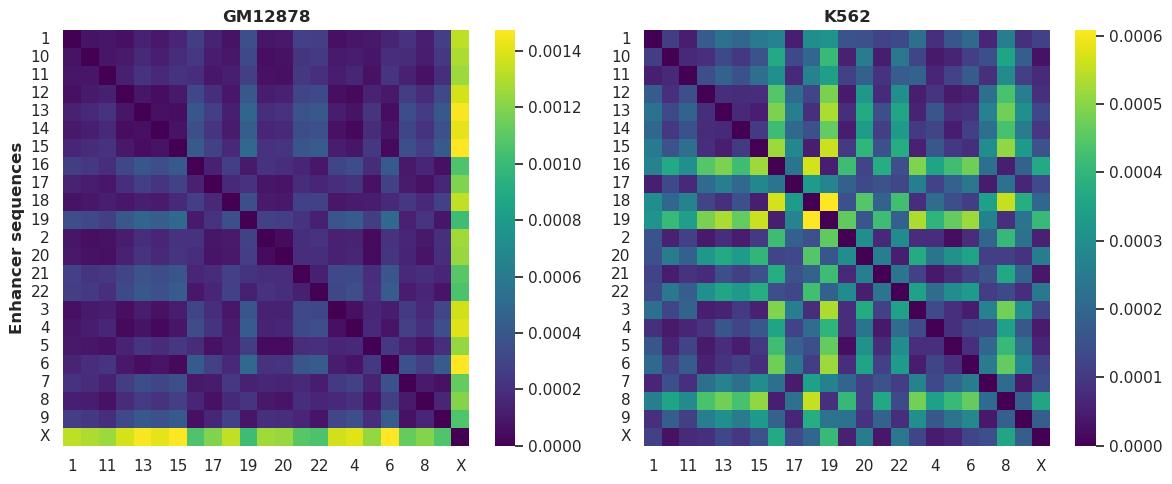

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(wd_gm_df, annot=False, fmt=".2f", cmap='viridis', ax=ax[0])
ax[0].set_title('GM12878', fontsize=12, weight="bold")
ax[0].set_ylabel('Enhancer sequences', fontsize=12, weight="bold")
sns.heatmap(wd_k5_df, annot=False, fmt=".1f", cmap='viridis', ax=ax[1])
ax[1].set_title('K562', fontsize=12, weight="bold")

#sns.heatmap(ev_wd_gm_df, annot=False, fmt=".2f", cmap='viridis', ax=ax[1, 0])
#ax[1, 0].set_ylabel('Exon sequences', fontsize=12, weight="bold")

#sns.heatmap(ev_wd_k5_df, annot=False, fmt=".1f", cmap='viridis', ax=ax[1, 1])
fig.tight_layout()
fig.show()